# Covariance shrinkage: α sweep and cell-type composition check

Follow-up to `block_vs_dense_le_drivers.ipynb`. That notebook found that block LE and dense LE disagree mainly
because every tile covariance is rank-deficient (≤ 200 cells, ~380 genes, 1e-6 ridge). Hundreds of eigenvalues
sit at the floor, and their logs (≈ −13.8) dominate the distance. Shrinking toward a scaled identity,
`(1 − α)Σ + α·mean(diag Σ)·I`, brought the two metrics into agreement on kidney (1 niche).

This notebook asks two questions:

1. **α sweep on a multi-niche dataset.** Skin melanoma has 4 niches; kidney is kept as the 1-niche reference.
   The block metric is pooled across niches exactly as in `hc.compute_ground_truth`: each train tile is scored in its
   own niche's permutation and block layout, with the query projected into that layout.
2. **Are shrunk-metric neighbours biologically closer?** Agreement between two metrics does not show that either one is
   right. The independent check used here is cell-type composition, as in `benchmarks/composition_concordance.py`:
   - For each query, compute the JSD between the query tile's cell-type fractions and the mean fractions of its top-k
     tiles (base 2; 0 = identical).
   - The labels are 10x's `gene_expression_graphclust` clusters from each Xenium bundle's `analysis.tar.gz`. The h5ads
     carry no cell-type column.
   - These clusters are expression-derived, but they are independent of any LE metric.

What this notebook does *not* do: niches and blocks are still built from raw covariances, and the DAG itself is not
used. Shrinkage enters only when distances are computed. Rebuilding the index from shrunk covariances is the next step.

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "8")

import sys
import io
import tarfile
import time
from pathlib import Path

PROJECT_ROOT = Path("/home/NAShome/ghoss18/spindle_dev")
for p in (PROJECT_ROOT / "src", PROJECT_ROOT, PROJECT_ROOT / "benchmarks"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import jensenshannon
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
%matplotlib inline

import benchmarks.build_indexes as bidx

DATA_ROOT = Path("/home/NAShome/sarkah1/shared_data/insitupy_demo_data_xenium")
DATASETS = {
    "skin_melanoma": ("xenium_human_skin_melanoma.h5ad",
                      "xenium_hskin/output-XETG00000__slide_id__hskin/analysis.tar.gz"),
    "kidney_nondiseased": ("xenium_human_kidney_nondiseased.h5ad",
                           "xenium_hkidney/output-XETG0000__slide_id__hkidney/analysis.tar.gz"),
}
ALPHAS = [0.0, 0.01, 0.05, 0.1, 0.3]
KS = [1, 5, 10]
N_RANDOM = 100
FLOOR = 1e-6
OUT_DIR = PROJECT_ROOT / "HS_notebooks"
rng = np.random.default_rng(0)
print("Imports OK.")

Imports OK.


## 1. Build each dataset's split and niche/block layout

The settings match `dag_vs_true_le_distance.ipynb`: seed 73, 100 held-out tiles, resolution 0.2, min_final_size 15.
Each cell is then joined to its graphclust label by barcode. Zero-transcript cells, which graphclust leaves out, are excluded from the compositions.

In [2]:
def load_graphclust(tar_path):
    with tarfile.open(tar_path) as tf:
        member = next(m for m in tf.getmembers()
                      if m.name.endswith("gene_expression_graphclust/clusters.csv"))
        return pd.read_csv(io.BytesIO(tf.extractfile(member).read())).set_index("Barcode")["Cluster"]

def prepare(name):
    h5ad, tar_rel = DATASETS[name]
    adata, genes, tr_tiles, tr_covs, te_tiles, te_covs, tr_idx, te_idx = bidx.load_and_split_data(
        DATA_ROOT / h5ad, test_ratio=0.05, seed=73, n_holdout=100)
    data, _ = bidx.run_index(tr_tiles, tr_covs, genes, adata,
                             resolution=0.2, min_final_size=15, max_niche_size=1000)
    clusters = load_graphclust(DATA_ROOT / tar_rel)
    lab = clusters.reindex(adata.obs_names)
    # 10x leaves zero-transcript cells out of graphclust; they are left out of the composition fractions
    print(f"{name}: {int(lab.isna().sum())} of {len(lab)} cells have no graphclust label (excluded from compositions)")
    codes = pd.Categorical(lab).codes  # -1 = unlabeled
    n_types = codes.max() + 1
    def comp(tiles):
        c = np.stack([np.bincount(codes[t.idx][codes[t.idx] >= 0], minlength=n_types) for t in tiles]).astype(float)
        return c / c.sum(1, keepdims=True)
    return {
        "train": [c["cov"].astype(np.float64) for c in tr_covs],
        "test": [c["cov"].astype(np.float64) for c in te_covs],
        "n_train": np.array([c["n"] for c in tr_covs]),
        "labels": np.asarray(data.labels).astype(int),
        "perm_list": data.perm_list, "block_dict": data.block_dict,
        "comp_train": comp(tr_tiles), "comp_test": comp(te_tiles), "n_types": n_types,
    }

D = {}
for name in DATASETS:
    D[name] = prepare(name)
    d = D[name]
    niche_info = [(k, int((d["labels"] == k).sum()), len(d["block_dict"][k])) for k in sorted(set(d["labels"]))]
    print(f"{name}: p={d['train'][0].shape[0]}, {len(d['train'])} train / {len(d['test'])} test, "
          f"{d['n_types']} graphclust types, niches (id, tiles, blocks) = {niche_info}")

[2026-09-28 23:09:41,244] INFO spindle_dev.preprocessing: build_quadtree_tiles: dropping 19 low-density tile(s) (895 spot(s) total) whose density is far below typical.


Reading data from /home/NAShome/sarkah1/shared_data/insitupy_demo_data_xenium/xenium_human_skin_melanoma.h5ad...
Preparing data for indexing...


[2026-09-28 23:09:41,854] INFO spindle_dev.index: Clustering SPD-s using 'tree' distance.


[2026-09-28 23:09:41,872] INFO spindle_dev.index: Building ultrametric features from SPD matrices.


Total tiles: 932 | Training/Indexed: 832 | Held out/Testing: 100 (seed=73, n_holdout=100)


...

[2026-09-28 23:09:53,134] INFO spindle_dev.index: Computing mean correlation matrix for cluster 0


[2026-09-28 23:09:53,359] INFO spindle_dev.index: Finding adaptive block runs for cluster 0


[2026-09-28 23:09:53,460] INFO spindle_dev.index:  Chose t=0.9179402517379516 resulting in 193 blocks instead of 185 blocks would have gotten by default


[2026-09-28 23:09:53,478] INFO spindle_dev.index:  Final block runs for cluster 0: 18 blocks.


kidney_nondiseased: 49 of 97560 cells have no graphclust label (excluded from compositions)
kidney_nondiseased: p=377, 683 train / 100 test, 21 graphclust types, niches (id, tiles, blocks) = [(np.int64(0), 683, 18)]


## 2. Block and dense LE for each α

Shrinkage is applied per tile before any log. Both metrics use the same shrunk matrices:
- **block**: `Σ_b ‖ΔL_b‖/√b` in the train tile's niche layout, pooled across niches (as in `compute_ground_truth`);
- **dense**: `‖ΔL‖/√p` on the full matrix.

In [3]:
def logm(M):
    w, V = np.linalg.eigh(0.5 * (M + M.T))
    return (V * np.log(np.maximum(w, FLOOR))) @ V.T

def sqdist(A, B):
    return np.maximum((A * A).sum(1)[:, None] + (B * B).sum(1)[None, :] - 2 * A @ B.T, 0)

def shrink(M, a):
    return M if a == 0 else (1 - a) * M + a * np.mean(np.diag(M)) * np.eye(M.shape[0])

def distances(d, a):
    S_te = [shrink(C, a) for C in d["test"]]
    S_tr = [shrink(C, a) for C in d["train"]]
    nq, nt, p = len(S_te), len(S_tr), S_te[0].shape[0]
    L = np.stack([logm(M).ravel() for M in S_te + S_tr])
    dense = np.sqrt(sqdist(L[:nq], L[nq:])) / np.sqrt(p)
    block = np.zeros((nq, nt))
    for k in sorted(set(d["labels"])):
        perm, runs = d["perm_list"][k], d["block_dict"][k]
        idx = np.where(d["labels"] == k)[0]
        for s, e in runs:
            g = perm[s:e]
            Q = np.stack([logm(M[np.ix_(g, g)]).ravel() for M in S_te])
            T = np.stack([logm(S_tr[j][np.ix_(g, g)]).ravel() for j in idx])
            block[:, idx] += np.sqrt(sqdist(Q, T)) / np.sqrt(e - s)
    return block, dense

dist = {}
for name, d in D.items():
    for a in ALPHAS:
        t0 = time.time()
        dist[name, a] = distances(d, a)
        print(f"{name:20s} alpha={a:<5} {time.time() - t0:.0f}s")

skin_melanoma        alpha=0.0   4s


skin_melanoma        alpha=0.01  5s


skin_melanoma        alpha=0.05  5s


skin_melanoma        alpha=0.1   5s


skin_melanoma        alpha=0.3   5s


kidney_nondiseased   alpha=0.0   3s


kidney_nondiseased   alpha=0.01  4s


kidney_nondiseased   alpha=0.05  4s


kidney_nondiseased   alpha=0.1   4s


kidney_nondiseased   alpha=0.3   4s


## 3. Agreement between block and dense LE as α grows

Columns:
- `rho_all`: per-query Spearman between block and dense distances over all train tiles.
- `rho_within_niche`: the same, restricted to the block NN's niche.
- `top1_agree` / `niche_agree`: the two metrics pick the same NN tile / an NN in the same niche.
- `denseNN_in_block_top10`: the dense NN appears in the block top-10.
- `block_top10_overlap_vs_raw`: fraction of the block top-10 that is unchanged from the α = 0 block top-10.
  It shows how far shrinkage moves the index's own ground truth, and is 1 at α = 0 by construction.
- `*_NN_cells` and `block~ncells_rho` track the cell-count artifact.

In [4]:
def spearman_rows(A, B, mask=None):
    return np.array([stats.spearmanr(A[i] if mask is None else A[i, mask[i]],
                                     B[i] if mask is None else B[i, mask[i]]).statistic for i in range(len(A))])

rows = []
for name, d in D.items():
    lab, n_train = d["labels"], d["n_train"]
    b0 = dist[name, 0.0][0]
    for a in ALPHAS:
        block, dense = dist[name, a]
        nq = len(block)
        bnn, dnn = block.argmin(1), dense.argmin(1)
        same_niche = lab[None, :] == lab[bnn][:, None]
        rank_dnn = np.argsort(np.argsort(block, 1), 1)[np.arange(nq), dnn]
        rows.append({
            "dataset": name, "alpha": a,
            "rho_all": spearman_rows(block, dense).mean(),
            "rho_within_niche": spearman_rows(block, dense, same_niche).mean(),
            "top1_agree": (bnn == dnn).mean(),
            "niche_agree": (lab[bnn] == lab[dnn]).mean(),
            "denseNN_in_block_top10": (rank_dnn < 10).mean(),
            "block_top10_overlap_vs_raw": np.mean([len(set(np.argsort(b0[i])[:10]) & set(np.argsort(block[i])[:10])) / 10
                                                   for i in range(nq)]),
            "blockNN_cells": np.median(n_train[bnn]), "denseNN_cells": np.median(n_train[dnn]),
            "block~ncells_rho": spearman_rows(block, np.broadcast_to(n_train, block.shape)).mean(),
        })
agree = pd.DataFrame(rows)
agree.to_csv(OUT_DIR / "shrinkage_alpha_sweep_agreement.csv", index=False)
agree.round(3)

,dataset,alpha,rho_all,rho_within_niche,top1_agree,niche_agree,denseNN_in_block_top10,block_top10_overlap_vs_raw,blockNN_cells,denseNN_cells,block~ncells_rho
0,skin_melanoma,0.00,0.286,-0.020,0.01,0.77,0.07,1.000,147.0,40.5,-0.372
1,skin_melanoma,0.01,0.730,0.723,0.07,0.85,0.34,0.400,142.0,66.5,-0.123
2,skin_melanoma,0.05,0.868,0.894,0.13,0.84,0.60,0.283,136.5,103.5,-0.065
3,skin_melanoma,0.10,0.917,0.937,0.22,0.84,0.74,0.227,136.0,128.0,-0.047
4,skin_melanoma,0.30,0.966,0.972,0.43,0.87,0.84,0.160,136.0,140.5,-0.016
5,kidney_nondiseased,0.00,0.208,0.208,0.00,1.00,0.06,1.000,161.0,124.0,-0.624
6,kidney_nondiseased,0.01,0.905,0.905,0.20,1.00,0.73,0.114,141.0,128.0,-0.263
7,kidney_nondiseased,0.05,0.935,0.935,0.32,1.00,0.81,0.082,137.5,129.5,-0.157
8,kidney_nondiseased,0.10,0.945,0.945,0.37,1.00,0.82,0.066,132.5,130.5,-0.130
9,kidney_nondiseased,0.30,0.966,0.966,0.41,1.00,0.87,0.049,127.0,132.0,-0.101


## 4. Composition check: do shrunk-metric neighbours share the query's cell-type mix?

For each query and each k ∈ {1, 5, 10}, the JSD between the query's graphclust composition and the mean composition of
the top-k tiles is computed under:
- **block α** and **dense α**, for every α (α = 0 is the current metric);
- **random**: k train tiles drawn uniformly, averaged over 100 draws;
- **random same niche**: k tiles drawn from the niche of the α = 0 block top-1. This is what niche membership alone gives.

Lower JSD is better. `wilcoxon_p_vs_block_raw` is a paired, two-sided test over queries against block α = 0.

In [5]:
def jsd(p, q):
    return float(jensenshannon(p, q, base=2) ** 2)

jsd_rows = []
for name, d in D.items():
    ct, cq, lab = d["comp_train"], d["comp_test"], d["labels"]
    nq, nt = len(cq), len(ct)
    bnn_raw = dist[name, 0.0][0].argmin(1)
    for i in range(nq):
        for k in KS:
            for a in ALPHAS:
                for metric, M in zip(("block", "dense"), dist[name, a]):
                    top = np.argsort(M[i])[:k]
                    jsd_rows.append({"dataset": name, "query": i, "k": k, "method": f"{metric} a={a}",
                                     "jsd": jsd(cq[i], ct[top].mean(0))})
            r = np.mean([jsd(cq[i], ct[rng.choice(nt, k, replace=False)].mean(0)) for _ in range(N_RANDOM)])
            pool = np.where(lab == lab[bnn_raw[i]])[0]
            rs = np.mean([jsd(cq[i], ct[rng.choice(pool, min(k, len(pool)), replace=False)].mean(0))
                          for _ in range(N_RANDOM)])
            jsd_rows += [{"dataset": name, "query": i, "k": k, "method": "random", "jsd": r},
                         {"dataset": name, "query": i, "k": k, "method": "random same niche", "jsd": rs}]
jsd_df = pd.DataFrame(jsd_rows)
jsd_df.to_csv(OUT_DIR / "shrinkage_composition_jsd.csv", index=False)

summ = []
for (name, k, method), g in jsd_df.groupby(["dataset", "k", "method"], sort=False):
    ref = jsd_df[(jsd_df.dataset == name) & (jsd_df.k == k) & (jsd_df.method == "block a=0.0")].set_index("query")["jsd"]
    x = g.set_index("query")["jsd"].loc[ref.index]
    p = np.nan if method == "block a=0.0" else wilcoxon(x, ref).pvalue
    summ.append({"dataset": name, "k": k, "method": method, "mean_jsd": x.mean(), "median_jsd": x.median(),
                 "frac_queries_better_than_block_raw": (x < ref).mean(), "wilcoxon_p_vs_block_raw": p})
summary = pd.DataFrame(summ)
summary.to_csv(OUT_DIR / "shrinkage_composition_summary.csv", index=False)

In [6]:
view = summary[summary.method.isin(["block a=0.0", "block a=0.1", "block a=0.3", "dense a=0.0", "dense a=0.1",
                                    "random same niche", "random"])]
view.pivot_table(index=["dataset", "method"], columns="k", values="mean_jsd", sort=False).round(4)

k                                         1       5       10
dataset            method                                   
skin_melanoma      block a=0.0        0.1833  0.1348  0.1350
                   dense a=0.0        0.2598  0.1615  0.1401
                   block a=0.1        0.1237  0.0880  0.0905
                   dense a=0.1        0.1295  0.0929  0.0934
                   block a=0.3        0.1267  0.0953  0.1008
                   random             0.5768  0.4379  0.4111
                   random same niche  0.3802  0.2786  0.2634
kidney_nondiseased block a=0.0        0.1883  0.1333  0.1295
                   dense a=0.0        0.1193  0.0837  0.0865
                   block a=0.1        0.1171  0.0837  0.0865
                   dense a=0.1        0.1126  0.0807  0.0790
                   block a=0.3        0.1219  0.0934  0.0960
                   random             0.2972  0.2122  0.1995
                   random same niche  0.2962  0.2131  0.1991

In [7]:
summary[summary.method.str.startswith("block") | summary.method.str.startswith("dense")].round(4)

,dataset,k,method,mean_jsd,median_jsd,frac_queries_better_than_block_raw,wilcoxon_p_vs_block_raw
0,skin_melanoma,1,block a=0.0,0.1833,0.1443,0.00,NaN
1,skin_melanoma,1,dense a=0.0,0.2598,0.2050,0.37,0.0005
2,skin_melanoma,1,block a=0.01,0.1165,0.0838,0.62,0.0000
3,skin_melanoma,1,dense a=0.01,0.2199,0.1511,0.46,0.3115
4,skin_melanoma,1,block a=0.05,0.1200,0.1018,0.64,0.0000
5,skin_melanoma,1,dense a=0.05,0.1364,0.1172,0.60,0.0035
6,skin_melanoma,1,block a=0.1,0.1237,0.1032,0.66,0.0001
7,skin_melanoma,1,dense a=0.1,0.1295,0.1086,0.61,0.0024
8,skin_melanoma,1,block a=0.3,0.1267,0.1045,0.62,0.0002
9,skin_melanoma,1,dense a=0.3,0.1199,0.1045,0.61,0.0001


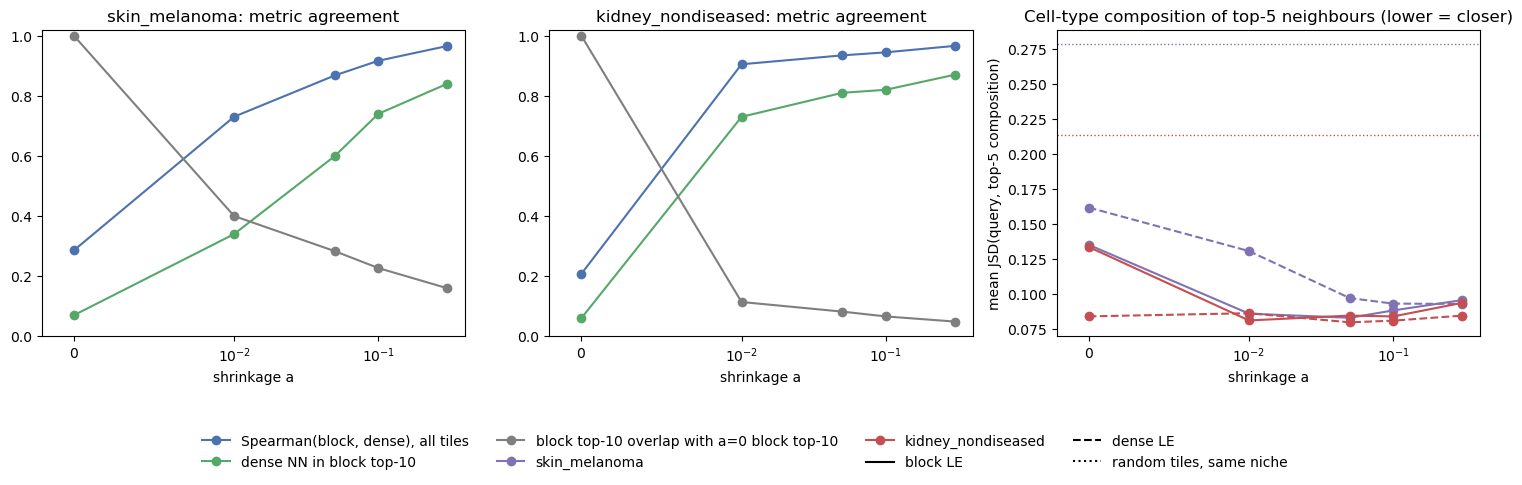

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
names = list(DATASETS)
agree_series = [("rho_all", "#4C72B0", "Spearman(block, dense), all tiles"),
                ("denseNN_in_block_top10", "#55A868", "dense NN in block top-10"),
                ("block_top10_overlap_vs_raw", "#7f7f7f", "block top-10 overlap with a=0 block top-10")]
for ax, name in zip(axes[:2], names):
    a_df = agree[agree.dataset == name]
    for col, c, lab in agree_series:
        ax.plot(a_df.alpha, a_df[col], marker="o", color=c, label=lab)
    ax.set_xscale("symlog", linthresh=0.01); ax.set_xlim(-0.002, 0.4); ax.set_ylim(0, 1.02)
    ax.set_xlabel("shrinkage a"); ax.set_title(f"{name}: metric agreement")
h1, l1 = axes[0].get_legend_handles_labels()

ax = axes[2]
k = 5
ds_color = dict(zip(names, ["#8172B3", "#C44E52"]))
for name in names:
    for metric, ls in (("block", "-"), ("dense", "--")):
        s = summary[(summary.dataset == name) & (summary.k == k) & summary.method.str.startswith(metric + " ")]
        ax.plot([float(m.split("=")[1]) for m in s.method], s.mean_jsd, color=ds_color[name], ls=ls, marker="o")
    rs = summary[(summary.dataset == name) & (summary.k == k) & (summary.method == "random same niche")].mean_jsd.item()
    ax.axhline(rs, color=ds_color[name], ls=":", lw=1)
ax.set_xscale("symlog", linthresh=0.01); ax.set_xlim(-0.002, 0.4)
ax.set_xlabel("shrinkage a"); ax.set_ylabel(f"mean JSD(query, top-{k} composition)")
ax.set_title(f"Cell-type composition of top-{k} neighbours (lower = closer)")
h2 = [plt.Line2D([], [], color=ds_color[n], marker="o", label=n) for n in names] + [
      plt.Line2D([], [], color="k", ls="-", label="block LE"), plt.Line2D([], [], color="k", ls="--", label="dense LE"),
      plt.Line2D([], [], color="k", ls=":", label="random tiles, same niche")]

fig.legend(h1 + h2, l1 + [h.get_label() for h in h2], loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(rect=(0, 0.12, 1, 1))
plt.show()

## 5. Findings

The numbers below are from the run saved in this notebook.

**Metric agreement (section 3).** Shrinkage fixes the block/dense disagreement on the multi-niche dataset too, but
skin needs more of it than kidney:

| | α = 0 | α = 0.01 | α = 0.1 | α = 0.3 |
|---|---|---|---|---|
| skin: ρ(block, dense) | 0.29 | 0.73 | 0.92 | 0.97 |
| kidney: ρ(block, dense) | 0.21 | 0.91 | 0.95 | 0.97 |

- Skin's raw within-niche ρ is about 0 (−0.02).
- On skin, the two metrics pick an NN in the same niche for about 85% of queries at every α > 0. The niches are still
  clustered from raw covariances, so part of the remaining gap may close once the index is rebuilt from shrunk ones.
- The cell-count artifact disappears. At α = 0, the skin dense NN is a tiny tile (median 40 cells vs. 147 for the block NN).
  By α = 0.1 the two medians are 128 and 136, and the block metric's correlation with cell count falls from −0.37 to −0.05.

**Composition (section 4): shrunk neighbours are biologically closer.** Mean JSD to the top-5 neighbours' mix:

| | block α = 0 (current) | block α = 0.1 | random, same niche |
|---|---|---|---|
| skin | 0.135 | 0.088 | 0.279 |
| kidney | 0.133 | 0.084 | 0.213 |

- That is about 35% lower. Block α = 0.1 beats block α = 0 on 71% (skin) and 84% (kidney) of queries, with Wilcoxon p < 1e-4.
- The same holds at k = 1 and k = 10.
- On skin, the best block α is about 0.01–0.1. α = 0.3 is slightly worse: at k = 10, JSD is 0.101 vs. 0.086 at α = 0.01–0.05.
  Heavier shrinkage starts to wash out real covariance structure.
- On kidney, raw *dense* already beats raw *block* (0.084 vs. 0.133 at k = 5). The raw block metric's pull toward large
  tiles costs it compositional fidelity there.

**Recommendation.** Use a fixed α of about 0.05–0.1, which is best or near-best for block LE on both datasets. It is enough
for ρ > 0.9 on skin and removes the cell-count bias; the metric-agreement gains beyond 0.1 cost composition.

**Caveats.**
- This covers two datasets and one seed.
- Graphclust labels are expression-derived, so they are independent of the LE metric but not of the data.
- Niches and blocks were not rebuilt. The next step is to rebuild the index from shrunk covariances and rerun the holdout
  benchmark (recall, speed).
- Niche clustering differs slightly between the `spatial_cpu` and `spindle_env` environments (skin niche sizes change);
  kidney is identical in both.